# 07 · 樹模型與特徵重要性

決策樹用一連串「是非題」做判斷，**人看得懂、還會告訴你哪些特徵最重要**。把很多棵樹合起來投票，就是橫掃各種表格資料競賽的**隨機森林**。這一課把這條線走完。

## 學習目標

- 訓練 `DecisionTreeClassifier` 並把樹**畫出來**
- 觀察 `max_depth` 如何造成**過擬合**
- 用 `RandomForestClassifier` 提升表現
- 讀 `feature_importances_`，知道模型最看重哪些特徵

## 1. 決策樹：一連串是非題

決策樹就是不斷問「某個特徵 > 某個值嗎？」把資料一分為二，直到每個葉子夠純。最棒的是它能**直接畫出來**，每個判斷都看得懂。

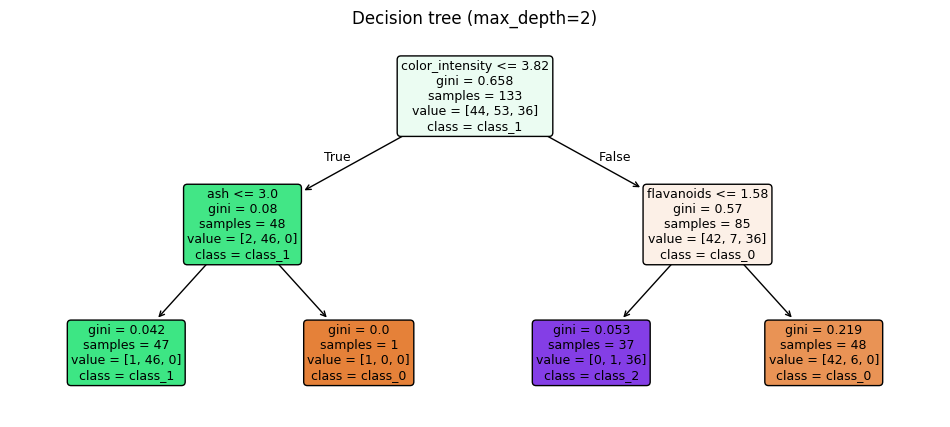

測試準確率: 86.7%


In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

wine = load_wine()
X, y = wine.data, wine.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

tree = DecisionTreeClassifier(max_depth=2, random_state=42).fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(12, 5))
plot_tree(tree, feature_names=wine.feature_names, class_names=wine.target_names,
          filled=True, rounded=True, fontsize=9, ax=ax)
ax.set_title("Decision tree (max_depth=2)")
plt.show()
print(f"測試準確率: {tree.score(X_test, y_test):.1%}")

順著樹從上往下讀：每個節點是一個是非題，往左或往右，最後落到某個葉子，那就是預測的類別。完全透明——這在需要**解釋決策**的場景（醫療、金融）非常重要。

## 2. max_depth 與過擬合

樹可以一直長到把訓練資料背得滾瓜爛熟（訓練準確率 100%），但那通常是在**背雜訊**，對新資料反而變差——這就是**過擬合**。我們掃不同深度，同時看訓練和測試準確率。

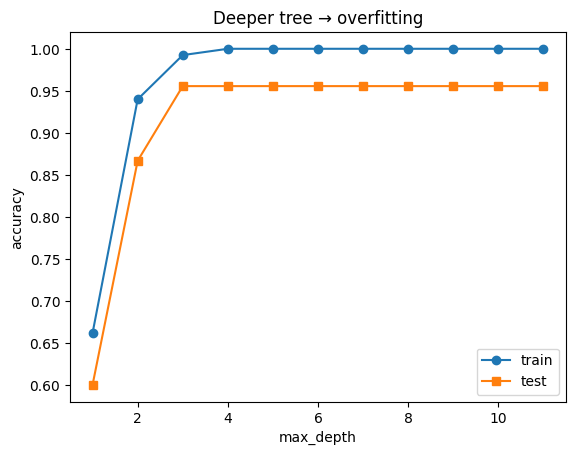

In [2]:
depths = range(1, 12)
train_acc, test_acc = [], []
for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
    train_acc.append(t.score(X_train, y_train))
    test_acc.append(t.score(X_test, y_test))

plt.plot(list(depths), train_acc, marker="o", label="train")
plt.plot(list(depths), test_acc, marker="s", label="test")
plt.xlabel("max_depth"); plt.ylabel("accuracy"); plt.legend()
plt.title("Deeper tree → overfitting")
plt.show()

看到了嗎：訓練準確率隨深度一路衝到 100%，但測試準確率到某個深度就停滯甚至下滑——兩條線拉開的縫隙，就是過擬合的程度。

## 3. 隨機森林：三個臭皮匠

單一棵樹容易過擬合、也不穩。**隨機森林**種很多棵「看資料不同子集、用特徵不同子集」的樹，最後投票——大幅降低過擬合，表現通常一棒打趴單棵樹，是表格資料的常勝軍。

In [3]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=200, random_state=42).fit(X_train, y_train)
print(f"單棵樹（深度不限）測試準確率: "
      f"{DecisionTreeClassifier(random_state=42).fit(X_train, y_train).score(X_test, y_test):.1%}")
print(f"隨機森林（200 棵）測試準確率: {forest.score(X_test, y_test):.1%}")

單棵樹（深度不限）測試準確率: 95.6%
隨機森林（200 棵）測試準確率: 100.0%


## 4. 特徵重要性：模型最看重什麼？

樹模型會記錄每個特徵對「把資料分乾淨」貢獻了多少，加總就是 `feature_importances_`。這是它的一大賣點——不只給預測，還告訴你**為什麼**。

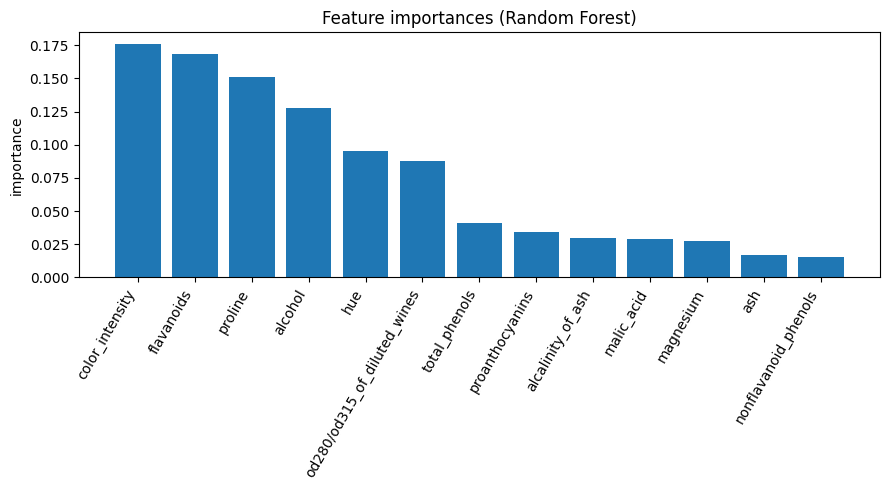

最重要的 3 個特徵:
  color_intensity              0.176
  flavanoids                   0.169
  proline                      0.151


In [4]:
import numpy as np

importances = forest.feature_importances_
order = np.argsort(importances)[::-1]   # 由大到小

plt.figure(figsize=(9, 5))
plt.bar(range(len(importances)), importances[order])
plt.xticks(range(len(importances)),
           np.array(wine.feature_names)[order], rotation=60, ha="right")
plt.ylabel("importance"); plt.title("Feature importances (Random Forest)")
plt.tight_layout()
plt.show()

print("最重要的 3 個特徵:")
for i in order[:3]:
    print(f"  {wine.feature_names[i]:<28} {importances[i]:.3f}")

## 小結

- 決策樹用是非題分類，**可以畫出來、人看得懂**。
- `max_depth` 太大會**過擬合**：訓練分數高、測試分數差。
- **隨機森林**集合多棵樹投票，更穩更準，是表格資料的首選。
- `feature_importances_` 告訴你模型最看重哪些特徵。

## 練習

1. 調 `n_estimators`（50 / 200 / 500），準確率與訓練時間怎麼變？
2. 把森林的特徵重要性和**單棵深樹**的比較，排序一樣嗎？

最後一課，我們把前七課的所有招式串成一條**完整的實戰流程**。